In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile
from typing import Literal
import math

## 1. Grover Algorithm

It is a Quantum algorithm that provides a significant speedup for searching through an unstructured database or solving "needle-in-a-haystack" problems.

##### Why is it better than Classical?

If you have an unsorted list of $N$ items and you are looking for one specific item.

- Classical Search: On average, you have to check $N/2$ items. In the worst case, you check $N$ items. This is $O(N)$ complexity.
- Grover’s Algorithm: You can find the item in approximately $\sqrt{N}$ steps. This is $O(\sqrt{N})$ complexity.

In [2]:
str_tmpl = "sample {i}"
items = list([str_tmpl.format(i=i) for i in range(16)])
answer = str_tmpl.format(i=10)

### 1.1 Using a Classical Search Comparison

In [3]:
class ClassicalAlgorithm:

    def __init__(self, _items):
        self.items = _items

    def _oracle(self, number, _answer):
        return number == _answer

    def search(self, _answer):
        for index, number in enumerate(self.items):
            if self._oracle(number, _answer):
                print("Execution count: ", index + 1)
                break

In [4]:
ca = ClassicalAlgorithm(items)
ca.search(answer)

Execution count:  11


### 1.2 Using the Grover Search Algorithm

##### Step 1: Initialization

1. **Qubit Calculation**: It calculates $n$ (the number of qubits) needed to represent the list. Since $2^n$ states are available with $n$ qubits, it ensures the list length matches exactly a power of 

2. **Equal Superposition**: Apply Hadamard $H$ gates to all qubits to put the Quantum computer into a state where it "considers" every item in the list simultaneously with equal probability.

##### Step 2: The Oracle

The Oracle's job is to "mark" the correct answer by flipping its phase.

1. **Binary Mapping**: Converts the index of the target item into a binary string.

2. **The X-Gate Sandwich**: Since a standard Multi-Controlled X (MCX) gate triggers on "1"s, the code applies $X$ (NOT) gates to any bit that is a "0" in the target index. This temporarily turns the target state into the $|11...1\rangle$ state so the MCX gate can recognize it.

3. **Phase Flip**: The combination of $H$ → $MCX$ → $H$ on the last qubit is a common trick to perform a Phase Kickback. It flips the sign (amplitude) of the target state from positive to negative.

4. **Cleanup**: Apply $X$-gates again to return the non-target qubits to their original state.

##### Step 3: The Reflection/Diffusion

This step is the "Amplifier" where it flips all amplitudes around the average value. 

The $H$ and $X$ Gates transforms the state to prepare for a reflection about the "all-zeros" state.

Similar to the Oracle, it uses a Multi-Controlled $X$ gate wrapped in Hadamards $H$ to flip the phase of the system's states. Because the "winner" had a negative amplitude from the Oracle, this step pushes the winner's amplitude significantly higher while suppressing the "losers."

In [5]:
class GroverAlgorithm:

    def __init__(self, _items):
        self.items = _items
        self.n = max(1, math.ceil(math.log2(len(items))))

        if len(self.items) != 2 ** self.n:
            raise ValueError("_items length must be a power of 2")

        self.mc = QuantumCircuit(self.n, self.n)
        self.mc.h(range(self.n))

    def _set_oracle_circuit(self, _answer):
        self.oc = QuantumCircuit(self.n, name="oracle-circuit")
        bits = format(self.items.index(_answer), f"0{self.n}b")

        for index, bit in enumerate(reversed(bits)):
            if bit == "0":
                self.oc.x(index)

        if self.n == 1:
            self.oc.z(0)
        else:
            self.oc.h(self.n - 1)
            self.oc.mcx(list(range(self.n - 1)), self.n - 1)
            self.oc.h(self.n - 1)
        
        for index, bit in enumerate(reversed(bits)):
            if bit == "0":
                self.oc.x(index)

        self.oc.to_gate()
        self.mc.append(self.oc, range(self.n))

    def _set_reflection_circuit(self):
        self.rc = QuantumCircuit(self.n, name='reflection-circuit')
        self.rc.h(range(self.n))
        self.rc.x(range(self.n))

        if self.n == 1:
            self.rc.z(0)
        else:
            self.rc.h(self.n - 1)
            self.rc.mcx(list(range(self.n - 1)), self.n - 1)
            self.rc.h(self.n - 1)

        self.rc.x(range(self.n))
        self.rc.h(range(self.n))
        self.rc.to_gate()
        self.mc.append(self.rc, range(self.n))

    def search(self, _answer):
        self._set_oracle_circuit(_answer)
        self._set_reflection_circuit()
        self.mc.measure(range(self.n), range(self.n))

    def compute(self):
        qasm_simulator = Aer.get_backend('qasm_simulator')
        statevector_simulator = Aer.get_backend('statevector_simulator')
        compiled_circuit = transpile(self.mc, backend=qasm_simulator)
        job = statevector_simulator.run(compiled_circuit, shots=1024)
        return job.result().get_counts()

In [6]:
ga = GroverAlgorithm(items)
ga.search(answer)

Viewing the Oracle Circuit

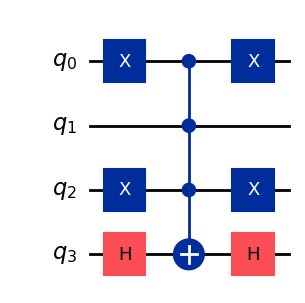

In [7]:
ga.oc.draw(output='mpl')

Viewing the Reflection Circuit

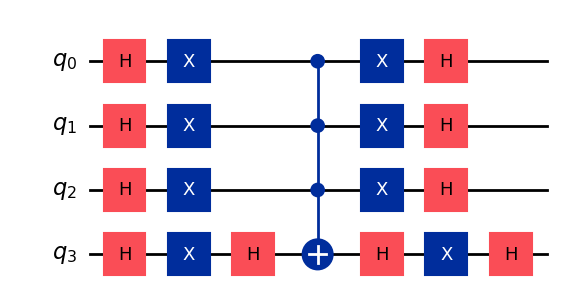

In [8]:
ga.rc.draw(output='mpl')

Viewing the Main Circuit

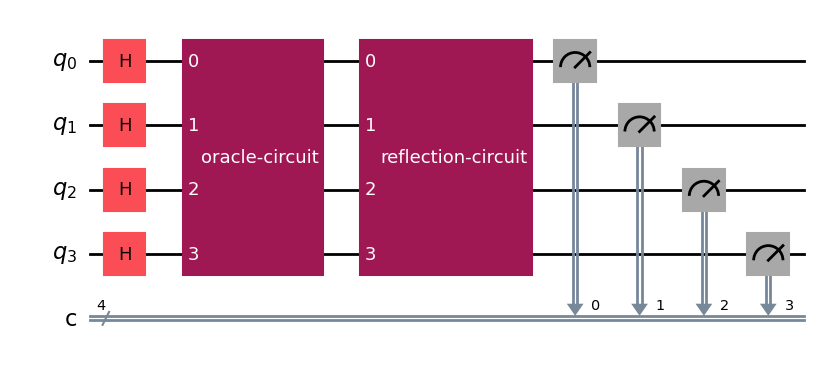

In [9]:
ga.mc.draw(output='mpl')

In [10]:
import pandas as pd

def bits_table(items):
    n = (len(items) - 1).bit_length()
    return pd.DataFrame({
        "bits": [format(i, f"0{n}b") for i in range(len(items))],
        "value": items,
    })

print(bits_table(items))

    bits      value
0   0000   sample 0
1   0001   sample 1
2   0010   sample 2
3   0011   sample 3
4   0100   sample 4
5   0101   sample 5
6   0110   sample 6
7   0111   sample 7
8   1000   sample 8
9   1001   sample 9
10  1010  sample 10
11  1011  sample 11
12  1100  sample 12
13  1101  sample 13
14  1110  sample 14
15  1111  sample 15


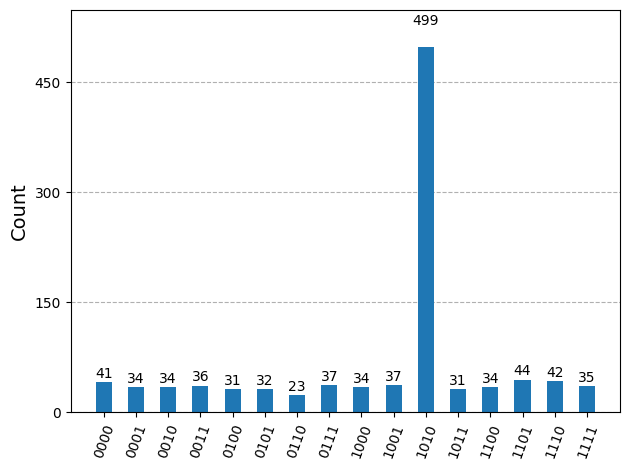

In [11]:
counts = ga.compute()
plot_histogram(counts)

## 2. Dinner Party

This demonstrates how the Grover’s algorithm identifies the valid guest list by considering all combinations simultaneously in superposition, using a logical oracle to "mark" satisfying states with a phase flip and an amplification step to boost their probability, ultimately finding the "needle in the haystack" with a quadratic speedup over classical searching.

##### Steps

1. The computer starts by considering every possible guest list simultaneously (for 5 guests, that is all 32 combinations at once).
2. The logical rules are converted into a "filter." This Oracle checks all combinations at the same time and "marks" the valid ones by flipping their mathematical sign (phase).
3. The algorithm performs a "mirror" trick (diffusion) that boosts the probability of the marked states while shrinking the invalid ones.
4. The probability of the correct guest list is now so high that the computer collapses into the right answer.

In [12]:
!pip3 install qiskit-algorithms --break-system-packages

In [22]:
from qiskit.circuit.library import PhaseOracle
from qiskit_algorithms import Grover, AmplificationProblem
from qiskit.primitives import StatevectorSampler

# 1. Logic
logical_expression = '((James & Lars) | (Kirk | Lena)) & ~Rob & ~Lena'
names = sorted(['James', 'Lars', 'Kirk', 'Rob', 'Lena']) 
oracle = PhaseOracle(logical_expression, var_order=names)

# 2. Problem & Grover
problem = AmplificationProblem(oracle, is_good_state=oracle.evaluate_bitstring)
sampler = StatevectorSampler(seed=42) 
grover = Grover(sampler=sampler, iterations=1)

# 3. Run
result = grover.amplify(problem)

# 4. Corrected Results Loop
print(f"Variable Order (q0 to q4): {names}\n")
counts = result.circuit_results[0]
total_invited = set()

for key, prob in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    if prob > 0.07:
        found_high_prob = True
        # Handle key as string or int
        bitstring = key if isinstance(key, str) else format(key, f'0{len(names)}b')
        
        # Reverse for Little-Endian mapping (q0 is index 0 in names)
        bits_reversed = bitstring[::-1]
        invited = [names[i] for i, bit in enumerate(bits_reversed) if bit == '1']
        total_invited = total_invited.union(invited)
        
print(f"CONFIRMED GUESTS (Prob: {prob:.2%})")
print(f"Invited: {', '.join(total_invited)}")

Variable Order (q0 to q4): ['James', 'Kirk', 'Lars', 'Lena', 'Rob']

CONFIRMED GUESTS (Prob: 0.20%)
Invited: Lars, James, Kirk


/var/folders/td/rtvtvvjn3x1gfqswnc7bb6hm0000gn/T/ipykernel_15690/1965029848.py:8: DeprecationWarning: The class ``qiskit.circuit.library.phase_oracle.PhaseOracle`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.PhaseOracleGate instead.
  oracle = PhaseOracle(logical_expression, var_order=names)
